# 04_13 Pattern Mining - FPGrowth
Train FPGrowth and export association rules.

[COMMAND_SO]
Command 1

[COMMAND_MUC_DICH]
- Muc tieu nghiep vu: Khai pha association rules va visual top rules de phan tich cross-sell.
- Muc tieu ky thuat: Hien thi bang metric va top rules theo confidence/lift ngay tren notebook.

26/03/31 22:28:13 WARN Utils: Your hostname, Genius-Macbook.local resolves to a loopback address: 127.0.0.1; using 192.168.2.18 instead (on interface en0)
26/03/31 22:28:13 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/03/31 22:28:13 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


26/03/31 22:28:13 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/03/31 22:28:13 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.


{'model_family': 'pattern_mining', 'model_name': 'FPGrowth', 'transactions': 3236, 'freq_itemsets': 66, 'rules': 18}


,model_family,model_name,transactions,freq_itemsets,rules
0,pattern_mining,FPGrowth,3236,66,18


+----------------------------------+----------------------------------+-------------------+------------------+---------------------+
|antecedent                        |consequent                        |confidence         |lift              |support              |
+----------------------------------+----------------------------------+-------------------+------------------+---------------------+
|[dbb67791e405873b259e4656bf971246]|[18486698933fbb64af6c0a255f7dd64c]|1.0                |462.2857142857143 |0.0021631644004944375|
|[18486698933fbb64af6c0a255f7dd64c]|[dbb67791e405873b259e4656bf971246]|1.0                |462.2857142857143 |0.0021631644004944375|
|[f4f67ccaece962d013a4e1d7dc3a61f7]|[4fcb3d9a5f4871e8362dfedbdb02b064]|0.9444444444444444 |160.85380116959064|0.005253399258343634 |
|[4fcb3d9a5f4871e8362dfedbdb02b064]|[f4f67ccaece962d013a4e1d7dc3a61f7]|0.8947368421052632 |160.85380116959064|0.005253399258343634 |
|[e53e557d5a159f5aa2c5e995dfdf244b]|[36f60d45225e60c7da4558b070ce4b60

,antecedent,consequent,confidence,lift,support
0,[dbb67791e405873b259e4656bf971246],[18486698933fbb64af6c0a255f7dd64c],1.000000,462.285714,0.002163
1,[18486698933fbb64af6c0a255f7dd64c],[dbb67791e405873b259e4656bf971246],1.000000,462.285714,0.002163
2,[f4f67ccaece962d013a4e1d7dc3a61f7],[4fcb3d9a5f4871e8362dfedbdb02b064],0.944444,160.853801,0.005253
3,[4fcb3d9a5f4871e8362dfedbdb02b064],[f4f67ccaece962d013a4e1d7dc3a61f7],0.894737,160.853801,0.005253
4,[e53e557d5a159f5aa2c5e995dfdf244b],[36f60d45225e60c7da4558b070ce4b60],0.894737,60.320175,0.010507
5,[35afc973633aaeb6b877ff57b2793310],[99a4788cb24856965c36a24e339b6058],0.805556,50.130342,0.008962
6,[3f14d740544f37ece8a9e7bc8349797e],[36f60d45225e60c7da4558b070ce4b60],0.800000,53.933333,0.003708
7,[36f60d45225e60c7da4558b070ce4b60],[e53e557d5a159f5aa2c5e995dfdf244b],0.708333,60.320175,0.010507
8,[99a4788cb24856965c36a24e339b6058],[35afc973633aaeb6b877ff57b2793310],0.557692,50.130342,0.008962
9,[389d119b48cf3043d311335e499d9c6b],[422879e10f46682990de24d770e7f83d],0.392857,39.727679,0.003399


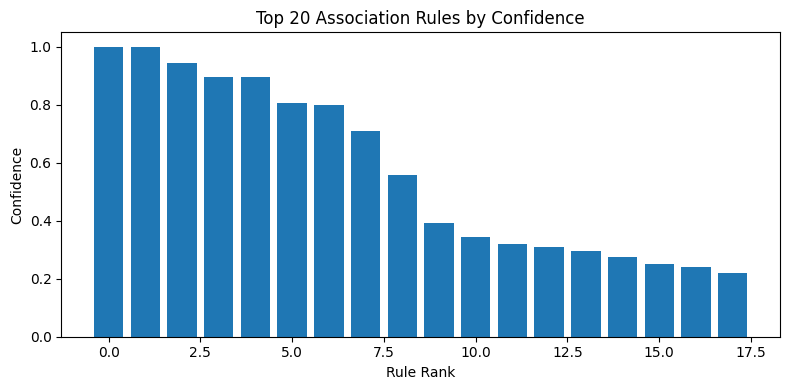

In [1]:
from pathlib import Path
import json
from pyspark.sql import SparkSession
from pyspark.ml.fpm import FPGrowth
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
spark=(SparkSession.builder.appName('04_13_fpgrowth').master('local[2]').config('spark.sql.shuffle.partitions','16').getOrCreate())
spark.sparkContext.setLogLevel('WARN')
PROJECT_ROOT=Path.cwd().resolve().parent if Path.cwd().name=='notebooks' else Path.cwd().resolve()
FEATURE_DIR=PROJECT_ROOT/'data'/'processed'/'features'
MODEL_DIR=PROJECT_ROOT/'models'/'pattern'/'fpgrowth'
METRIC_DIR=PROJECT_ROOT/'reports'/'model_metrics'
RULE_DIR=PROJECT_ROOT/'reports'/'association_rules'
MODEL_DIR.mkdir(parents=True, exist_ok=True)
METRIC_DIR.mkdir(parents=True, exist_ok=True)
RULE_DIR.mkdir(parents=True, exist_ok=True)
df=spark.read.parquet(str(FEATURE_DIR/'fpgrowth_ready')).select('order_id','items').dropna()
fp=FPGrowth(itemsCol='items',minSupport=0.002,minConfidence=0.2)
m=fp.fit(df)
freq=m.freqItemsets
rules=m.associationRules
metrics={'model_family':'pattern_mining','model_name':'FPGrowth','transactions':df.count(),'freq_itemsets':freq.count(),'rules':rules.count()}
print(metrics)
display(pd.DataFrame([metrics]))
m.write().overwrite().save(str(MODEL_DIR))
freq.write.mode('overwrite').parquet(str(RULE_DIR/'frequent_itemsets'))
rules.write.mode('overwrite').parquet(str(RULE_DIR/'association_rules'))
(METRIC_DIR/'pattern_fpgrowth.json').write_text(json.dumps(metrics,indent=2),encoding='utf-8')
top_rules=rules.orderBy('confidence', ascending=False).limit(20)
top_rules.show(20, truncate=False)
top_rules_pdf=top_rules.toPandas()
if not top_rules_pdf.empty:
    display(top_rules_pdf[['antecedent','consequent','confidence','lift','support']])
    plt.figure(figsize=(8,4))
    plt.bar(range(len(top_rules_pdf)), top_rules_pdf['confidence'])
    plt.title('Top 20 Association Rules by Confidence')
    plt.xlabel('Rule Rank')
    plt.ylabel('Confidence')
    plt.tight_layout()
    plt.show()